In [1]:
import numpy as np
import tensorflow as tf
import tensorflow.keras.layers as layers
import matplotlib.pyplot as plt
import math
from tensorflow.keras.models import Model
from tensorflow.keras.layers import BatchNormalization, Add, UpSampling3D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv3D, Input, MaxPooling3D, Dropout, concatenate, UpSampling3D, ReLU
from tensorflow.keras import backend as K
import nibabel as nib
import os 


def global_normalized_cross_correlation_loss():
    def ncc(y_true, y_pred):
        """Computes the normalized cross-correlation (NCC) loss.

        Parameters
        ----------
        y_true : tf.Tensor
            The static image to which the moving image is aligned.
        y_pred : tf.Tensor
            The moving image, the same shape as the static image.

        Returns
        -------
        loss : tf.Tensor, shape ()
            Normalized cross-correlation loss between the static and the
            moving images, averaged over the batch. Range is [-1.0, 1.0].
            The best value is -1 (perfect match) and the worst is 1.

        References
        ----------
        .. [1] `Wikipedia entry for the Cross-correlation
               <https://en.wikipedia.org/wiki/Cross-correlation>`_

        """
        ndim = tf.keras.backend.ndim(y_true)-2

        # shape (N, 1, 1, C)
        y_true_mean = tf.reduce_mean(y_true, axis=range(1, ndim+1),
                                     keepdims=True)
        y_pred_mean = tf.reduce_mean(y_pred, axis=range(1, ndim+1),
                                     keepdims=True)
        plt.ylabel('Loss')

        y_true_hat = tf.math.l2_normalize(y_true-y_true_mean,
                                          axis=range(1, ndim+1))

        y_pred_hat = tf.math.l2_normalize(y_pred-y_pred_mean,
                                          axis=range(1, ndim+1))

        return -tf.reduce_mean(tf.reduce_sum(y_true_hat * y_pred_hat,
                                             axis=range(1, ndim+1)))
    return ncc


def local_normalized_cross_correlation_loss(window=(9, 9, 9), eps=1e-5):
    """
    Code borrowed from https://github.com/voxelmorph/voxelmorph/blob/legacy/src/losses.py#L28
    Paper: https://openaccess.thecvf.com/content_cvpr_2018/papers/Balakrishnan_An_Unsupervised_Learning_CVPR_2018_paper.pdf
    """
    def ncc(I, J, window=window):
        # get dimension of volume
        # assumes I, J are sized [batch_size, *vol_shape, nb_feats]
        # ndims = len(I.get_shape().as_list()) - 2
        ndims = tf.keras.backend.ndim(I)-2
        assert ndims in [1, 2, 3], "volumes should be 1 to 3 dimensions. found: %d" % ndims

        # set window size
        if window is None:
            window = [9] * ndims

        # get convolution function
        conv_fn = getattr(tf.nn, 'conv%dd' % ndims)

        # compute CC squares
        I2 = I*I
        J2 = J*J
        IJ = I*J

        # compute filters
        sum_filt = tf.ones([*window, 1, 1])
        strides = [1] * (ndims + 2)
        padding = 'SAME'

        # compute local sums via convolution
        I_sum = conv_fn(I, sum_filt, strides, padding)
        J_sum = conv_fn(J, sum_filt, strides, padding)
        I2_sum = conv_fn(I2, sum_filt, strides, padding)
        J2_sum = conv_fn(J2, sum_filt, strides, padding)
        IJ_sum = conv_fn(IJ, sum_filt, strides, padding)

        # compute cross correlation
        win_size = np.prod(window)
        u_I = I_sum/win_size
        u_J = J_sum/win_size

        cross = IJ_sum - u_J*I_sum - u_I*J_sum + u_I*u_J*win_size
        I_var = I2_sum - 2 * u_I * I_sum + u_I*u_I*win_size
        J_var = J2_sum - 2 * u_J * J_sum + u_J*u_J*win_size

        cc = cross*cross / (I_var*J_var + eps)

        # return negative cc.
        return -tf.reduce_mean(cc)
    return ncc

# vein. Portal veins are well enhanced and some enhancement of the hepatic veins is also seen on the portal venous phase. T
def gradient_loss(norm=2):
    """
    Code borrowed from https://github.com/voxelmorph/voxelmorph/blob/legacy/pytorch/losses.py#L13
    Paper: https://openaccess.thecvf.com/content_cvpr_2018/papers/Balakrishnan_An_Unsupervised_Learning_CVPR_2018_paper.pdf
    """
    def grad_loss(_, phi):
        di = tf.abs(phi[:, 1:, :, :, :] - phi[:, :-1, :, :, :])
        dj = tf.abs(phi[:, :, 1:, :, :] - phi[:, :, :-1, :, :])
        dk = tf.abs(phi[:, :, :, 1:, :] - phi[:, :, :, :-1, :])

        loss = tf.reduce_mean(di) + tf.reduce_mean(dj) + tf.reduce_mean(dk)
        if norm == 2:
            loss = tf.reduce_mean(di**2) + tf.reduce_mean(dj**2) + tf.reduce_mean(dk**2)    
        return loss
    return grad_loss

def regular_grid_3d(depth, height, width):
    """Returns a 3-D regular grid.

    Parameters
    ----------
    depth : int
        The desired depth of the grid.
    height : int
        The desired height of the grid.
    width : int
        The desired width of the grid.
    Returns
    -------
    grid : tf.Tensor, shape (D, H, W, 3)
        A 3-D regular grid, values normalized to [-1.0, 1.0]
        range.

    Notes
    -----
    Sampling using the regular grid is an identity transformation, i.e.,
    it results in the same input and output images.

    References
    ----------
    .. [1] `NumPy, "numpy.meshgrid"
        <https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html>`_
    .. [2] `NumPy, "numpy.indices"
        <https://numpy.org/doc/stable/reference/generated/numpy.indices.html>`_
    moved = tf.add_n([moving_a,moving_b, moving_c,
                      moving_d,moving_e, moving_f,
                      moving_g, moving_h], name=name)

    """
    i = tf.linspace(-1.0, 1.0, depth)
    j = tf.linspace(-1.0, 1.0, height)
    k = tf.linspace(-1.0, 1.0, width)

    I, J, K = tf.meshgrid(i, j, k, indexing='ij')

    grid = tf.stack([I, J, K], axis=-1)
    return grid


def grid_sample_3d(moving, grid, name=None):
    """Given a moving image and a sampling grid as input, computes the
    transformed image by sampling the moving image at locations given by
    the grid.

    Parameters
    ----------
    moving : tf.Tensor, shape (N, D, H, W, C)
        The moving image.
    grid : tf.Tensor, shape (N, D, H, W, C)
        A tensor of sampling points (x, y, z). The x, y and z values should be
        normalized to [-1.0, 1.0] range.
    name : str
        Name for the operation.

    Returns
    -------
    moved : tf.Tensor, shape (N, D, H, W, C)
        The transformed image.

    Notes
    -----
    Let M be the moving image of shape (H, W, C), T be the transformed
    image of the same shape and G be the 2D sampling grid of shape
    (H, W, 2). The value of T at a location (x, y) is T[y, x, :] =
    M[y', x', :] where [x', y'] = G[y, x, :].

    Further, [x', y'] = [x + dx, y + dy] where [dx, dy] are the
    displacements outputted by the CNN. When dx and dy are 0, the
    sampling grid G is a regular grid and the transformed image is the
    same as the moving image.

    Since the sampling point (x + dx, y + dy) can be non-integral, the
    value M[y', x'] is calculated using bi-linear interpolation.
    
    => 이전 value를 가져오는 걸로 수정

    References
    ----------
    .. [1] `Jaderberg, Max, Karen Simonyan, and Andrew Zisserman. "Spatial
        transformer networks." Advances in neural information processing
        systems. 2015. <https://arxiv.org/abs/1506.02025>`_
    -------
    .. [2] `TensorFlow implementation of spatial transformer networks.
        <https://github.com/tensorflow/models/tree/master/research/transformer>`_
    .. [3] `Spatial Transformer Networks by Kushagra Bhatnagar
        <https://link.medium.com/0b2OrmqVO5>`_
        
    """
    nb, nd, nh, nw, nc = tf.shape(moving)
    
    i = grid[..., 0]  # shape (N, D, H, W)
    j = grid[..., 1]
    k = grid[..., 2]
    i = tf.cast(i, 'float32')
    j = tf.cast(j, 'float32')
    k = tf.cast(k, 'float32')

    # Scale i, j and k from [-1.0, 1.0] to [0, D], [0, H] and [0, W] respectively.
    i = (i + 1.0) * 0.5 * tf.cast(nd-1, 'float32')
    j = (j + 1.0) * 0.5 * tf.cast(nh-1, 'float32')
    k = (k + 1.0) * 0.5 * tf.cast(nw-1, 'float32')

    i_max = tf.cast(nd - 1, 'int32')
    j_max = tf.cast(nh - 1, 'int32')
    k_max = tf.cast(nw - 1, 'int32')
    zero = tf.constant(0, 'int32')

    # The value at (i, j, k) is a weighted average of the values at the
    # eight nearest integer locations: (i0, j0, k0), (i0, j0, k1), (i0, j1, k0),
    # (i0, j1, k1), (i1, j0, k0), (i1, j0, k1), (i1, j1, k0) and (i1, j1, k1)
    # where i0 = floor(i), i1 = ceil(i).
    i0 = tf.cast(tf.floor(i), 'int32')
    i1 = i0 + 1
    j0 = tf.cast(tf.floor(j), 'int32')
    j1 = j0 + 1
    k0 = tf.cast(tf.floor(k), 'int32')
    k1 = k0 + 1

    # Make sure indices are within the boundaries of the image.
    i0 = tf.clip_by_value(i0, zero, i_max)
    i1 = tf.clip_by_value(i1, zero, i_max)
    j0 = tf.clip_by_value(j0, zero, j_max)
    j1 = tf.clip_by_value(j1, zero, j_max)
    k0 = tf.clip_by_value(k0, zero, k_max)
    k1 = tf.clip_by_value(k1, zero, k_max)

    # Collect indices of the four corners.
    b = tf.ones_like(i0) * tf.reshape(tf.range(nb), [nb, 1, 1, 1])
    idx_a = tf.stack([b, i1, j0, k0], axis=-1)  # all front-top-left corners
    idx_b = tf.stack([b, i1, j1, k0], axis=-1)  # all front-bottom-left corners
    idx_c = tf.stack([b, i1, j0, k1], axis=-1)  # all front-top-right corners
    idx_d = tf.stack([b, i1, j1, k1], axis=-1)  # all front-bottom-right corners
    idx_e = tf.stack([b, i0, j0, k0], axis=-1)  # all back-top-left corners
    idx_f = tf.stack([b, i0, j1, k0], axis=-1)  # all back-bottom-left corners
    idx_g = tf.stack([b, i0, j0, k1], axis=-1)  # all back-top-right corners
    idx_h = tf.stack([b, i0, j1, k1], axis=-1)  # all back-bottom-right corners
    # shape (N, D, H, W, 3)
    # print(idx_a.shape)
    
    # Collect values at the corners.
    moving_a = tf.gather_nd(moving, idx_a)  # all front-top-left values
    moving_b = tf.gather_nd(moving, idx_b)  # all front-bottom-left values
    moving_c = tf.gather_nd(moving, idx_c)  # all front-top-right values
    moving_d = tf.gather_nd(moving, idx_d)  # all front-bottom-right values
    moving_e = tf.gather_nd(moving, idx_e)  # all back-top-left values
    moving_f = tf.gather_nd(moving, idx_f)  # all back-bottom-left values
    moving_g = tf.gather_nd(moving, idx_g)  # all back-top-right values
    moving_h = tf.gather_nd(moving, idx_h)  # all back-bottom-right values

    i0_f = tf.cast(i0, 'float32')
    i1_f = tf.cast(i1, 'float32')
    j0_f = tf.cast(j0, 'float32')
    j1_f = tf.cast(j1, 'float32')
    k0_f = tf.cast(k0, 'float32')
    k1_f = tf.cast(k1, 'float32')

    i = tf.cast(i, 'float32')
    j = tf.cast(j, 'float32')
    k = tf.cast(k, 'float32')

    i_r = tf.round(i)
    j_r = tf.round(j)
    k_r = tf.round(k)
    i_r = tf.cast(i_r, 'float32')
    j_r = tf.cast(j_r, 'float32')
    k_r = tf.cast(k_r, 'float32')

    _i0 = tf.equal(i_r, i0_f)
    _j0 = tf.equal(j_r, j0_f)
    _k0 = tf.equal(k_r, k0_f)
    _i1 = tf.equal(i_r, i1_f)
    _j1 = tf.equal(j_r, j1_f)
    _k1 = tf.equal(k_r, k1_f)
    
    _i0 = tf.cast(_i0, 'float32')
    _j0 = tf.cast(_j0, 'float32')
    _k0 = tf.cast(_k0, 'float32')
    _i1 = tf.cast(_i1, 'float32')
    _j1 = tf.cast(_j1, 'float32')
    _k1 = tf.cast(_k1, 'float32')
    
#     _i0 = tf.case([(tf.less(i_r, i1_f), f1)], default=f2)
#     _i1 = tf.case([tf.greater(i_r,i0_f), _one])
#     _j0 = tf.case([tf.less(j_r,j1_f), _one])
#     _j1 = tf.case([tf.greater(j_r,j0_f), _one])
#     _k0 = tf.case([tf.less(k_r,k1_f), _one])
#     _k1 = tf.case([tf.greater(k_r,k0_f), _one])

    
    # Calculate the weights.
#     wa = tf.expand_dims((i_r * (j1_f - j) * (k1_f - k), axis=-1)
#     wb = tf.expand_dims((i - i0_f) * (j - j0_f) * (k1_f - k), axis=-1)
#     wc = tf.expand_dims((i - i0_f) * (j1_f - j) * (k - k0_f), axis=-1)
#     wd = tf.expand_dims((i - i0_f) * (j - j0_f) * (k - k0_f), axis=-1)
#     we = tf.expand_dims((i1_f - i) * (j1_f - j) * (k1_f - k), axis=-1)
#     wf = tf.expand_dims((i1_f - i) * (j - j0_f) * (k1_f - k), axis=-1)
#     wg = tf.expand_dims((i1_f - i) * (j1_f - j) * (k - k0_f), axis=-1)
#     wh = tf.expand_dims((i1_f - i) * (j - j0_f) * (k - k0_f), axis=-1

    wa = tf.expand_dims(_i1 * _j0 * _k0, axis=-1)
    wb = tf.expand_dims(_i1 * _j1 * _k0, axis=-1)
    wc = tf.expand_dims(_i1 * _j0 * _k1, axis=-1)
    wd = tf.expand_dims(_i1 * _j1 * _k1, axis=-1)
    we = tf.expand_dims(_i0 * _j0 * _k0, axis=-1)
    wf = tf.expand_dims(_i0 * _j1 * _k0, axis=-1)
    wg = tf.expand_dims(_i0 * _j0 * _k1, axis=-1)
    wh = tf.expand_dims(_i0 * _j1 * _k1, axis=-1)
    
    total = wa+wb+wc+wd+we+wf+wg+wh
    
    # Calculate the weighted sum.
    moved = tf.add_n([wa * moving_a, wb * moving_b, wc * moving_c,
                      wd * moving_d, we * moving_e, wf * moving_f,
                      wg * moving_g, wh * moving_h], name=name)
    
    moved = tf.divide(moved, total)
    return moved

In [2]:
def grid_sample_3d2(moving, grid, name=None):
    """Given a moving image and a sampling grid as input, computes the
    transformed image by sampling the moving image at locations given by
    the grid.

    Parameters
    ----------
    moving : tf.Tensor, shape (N, D, H, W, C)
        The moving image.
    grid : tf.Tensor, shape (N, D, H, W, C)
        A tensor of sampling points (x, y, z). The x, y and z values should be
        normalized to [-1.0, 1.0] range.
    name : str
        Name for the operation.

    Returns
    -------
    moved : tf.Tensor, shape (N, D, H, W, C)
        The transformed image.

    Notes  
    -----
    Let M be the moving image of shape (H, W, C), T be the transformed
    image of the same shape and G be the 2D sampling grid of shape
    (H, W, 2). The value of T at a location (x, y) is T[y, x, :] =
    M[y', x', :] where [x', y'] = G[y, x, :].

    Further, [x', y'] = [x + dx, y + dy] where [dx, dy] are the
    displacements outputted by the CNN. When dx and dy are 0, the
    sampling grid G is a regular grid and the transformed image is the
    same as the moving image.

    Since the sampling point (x + dx, y + dy) can be non-integral, the
    value M[y', x'] is calculated using bi-linear interpolation.
    
    => 이전 value를 가져오는 걸로 수정

    References
    ----------
    .. [1] `Jaderberg, Max, Karen Simonyan, and Andrew Zisserman. "Spatial
        transformer networks." Advances in neural information processing
        systems. 2015. <https://arxiv.org/abs/1506.02025>`_
    .. [2] `TensorFlow implementation of spatial transformer networks.
        <https://github.com/tensorflow/models/tree/master/research/transformer>`_
    .. [3] `Spatial Transformer Networks by Kushagra Bhatnagar
        <https://link.medium.com/0b2OrmqVO5>`_
        
    """
    nb, nd, nh, nw, nc = tf.shape(moving)
    
    i = grid[..., 0]  # shape (N, D, H, W)
    j = grid[..., 1]
    k = grid[..., 2]
    i = tf.cast(i, 'float32')
    j = tf.cast(j, 'float32')
    k = tf.cast(k, 'float32')

    # Scale i, j and k from [-1.0, 1.0] to [0, D], [0, H] and [0, W] respectively.
    i = (i + 1.0) * 0.5 * tf.cast(nd-1, 'float32')
    j = (j + 1.0) * 0.5 * tf.cast(nh-1, 'float32')
    k = (k + 1.0) * 0.5 * tf.cast(nw-1, 'float32')

    i_max = tf.cast(nd - 1, 'int32')
    j_max = tf.cast(nh - 1, 'int32')
    k_max = tf.cast(nw - 1, 'int32')
    zero = tf.constant(0, 'int32')

    # The value at (i, j, k) is a weighted average of the values at the
    # eight nearest integer locations: (i0, j0, k0), (i0, j0, k1), (i0, j1, k0),
    # (i0, j1, k1), (i1, j0, k0), (i1, j0, k1), (i1, j1, k0) and (i1, j1, k1)
    # where i0 = floor(i), i1 = ceil(i).
    i0 = tf.cast(tf.floor(i), 'int32')
    i1 = i0 + 1
    j0 = tf.cast(tf.floor(j), 'int32')
    j1 = j0 + 1
    k0 = tf.cast(tf.floor(k), 'int32')
    k1 = k0 + 1

    # Make sure indices are within the boundaries of the image.
    i0 = tf.clip_by_value(i0, zero, i_max)
    i1 = tf.clip_by_value(i1, zero, i_max)
    j0 = tf.clip_by_value(j0, zero, j_max)
    j1 = tf.clip_by_value(j1, zero, j_max)
    k0 = tf.clip_by_value(k0, zero, k_max)
    k1 = tf.clip_by_value(k1, zero, k_max)

    # Collect indices of the four corners.
    b = tf.ones_like(i0) * tf.reshape(tf.range(nb), [nb, 1, 1, 1])
    idx_a = tf.stack([b, i1, j0, k0], axis=-1)  # all front-top-left corners
    idx_b = tf.stack([b, i1, j1, k0], axis=-1)  # all front-bottom-left corners
    idx_c = tf.stack([b, i1, j0, k1], axis=-1)  # all front-top-right corners
    idx_d = tf.stack([b, i1, j1, k1], axis=-1)  # all front-bottom-right corners
    idx_e = tf.stack([b, i0, j0, k0], axis=-1)  # all back-top-left corners
    idx_f = tf.stack([b, i0, j1, k0], axis=-1)  # all back-bottom-left corners
    idx_g = tf.stack([b, i0, j0, k1], axis=-1)  # all back-top-right corners
    idx_h = tf.stack([b, i0, j1, k1], axis=-1)  # all back-bottom-right corners
    # shape (N, D, H, W, 3)

    # Collect values at the corners.
    moving_a = tf.gather_nd(moving, idx_a)  # all front-top-left values
    moving_b = tf.gather_nd(moving, idx_b)  # all front-bottom-left values
    moving_c = tf.gather_nd(moving, idx_c)  # all front-top-right values
    moving_d = tf.gather_nd(moving, idx_d)  # all front-bottom-right values
    moving_e = tf.gather_nd(moving, idx_e)  # all back-top-left values
    moving_f = tf.gather_nd(moving, idx_f)  # all back-bottom-left values
    moving_g = tf.gather_nd(moving, idx_g)  # all back-top-right values
    moving_h = tf.gather_nd(moving, idx_h)  # all back-bottom-right values
    # shape (N, D, H, W, C)

    i0_f = tf.cast(i0, 'float32')
    i1_f = tf.cast(i1, 'float32')
    j0_f = tf.cast(j0, 'float32')
    j1_f = tf.cast(j1, 'float32')
    k0_f = tf.cast(k0, 'float32')
    k1_f = tf.cast(k1, 'float32')

    # Calculate the weights.
    wa = tf.expand_dims((i - i0_f) * (j1_f - j) * (k1_f - k), axis=-1)
    wb = tf.expand_dims((i - i0_f) * (j - j0_f) * (k1_f - k), axis=-1)
    wc = tf.expand_dims((i - i0_f) * (j1_f - j) * (k - k0_f), axis=-1)
    wd = tf.expand_dims((i - i0_f) * (j - j0_f) * (k - k0_f), axis=-1)
    we = tf.expand_dims((i1_f - i) * (j1_f - j) * (k1_f - k), axis=-1)
    wf = tf.expand_dims((i1_f - i) * (j - j0_f) * (k1_f - k), axis=-1)
    wg = tf.expand_dims((i1_f - i) * (j1_f - j) * (k - k0_f), axis=-1)
    wh = tf.expand_dims((i1_f - i) * (j - j0_f) * (k - k0_f), axis=-1)

    # Calculate the weighted sum.
    moved = tf.add_n([wa * moving_a, wb * moving_b, wc * moving_c,
                      wd * moving_d, we * moving_e, wf * moving_f,
                      wg * moving_g, wh * moving_h], name=name)
    return moved

In [3]:
class Dualstream(object):
    def __init__(self, input_shape=(64, 128, 128), optimizer='adam', loss=None,
                 metrics=None, loss_weights=None):
        in_channels = 1
        out_channels = 3
        input_shape = input_shape + (in_channels,)
#         self.reconstruction = Dense3DSpatialTransformer()
        
        moving = layers.Input(shape=input_shape, name='moving')
        static = layers.Input(shape=input_shape, name='static')
        moving_gt = layers.Input(shape=input_shape, name='moving_gt')
        
        
        def resblock(inputLayer,opName,channel):
            residual = inputLayer
            conv1_1 = layers.Conv3D(channel, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name= opName+'_1')(inputLayer)
            conv1_2 = layers.Conv3D(channel, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name= opName+'_2')(conv1_1)
            add1 = Add()([conv1_2, residual])
            return add1
        
        def Img_Moved(moving, dvf, names):
            
            nb, nd, nh, nw, nc = tf.shape(dvf)

            grid = regular_grid_3d(nd, nh, nw)  # shape (D, H, W, 2)

            grid = tf.expand_dims(grid, axis=0)  # shape (1, D, H, W, 2)
            multiples = tf.stack([nb, 1, 1, 1, 1])
            grid = tf.tile(grid, multiples)
            grid_new = grid + dvf
            
            grid_new = tf.clip_by_value(grid_new, -1, 1)

            moved = grid_sample_3d2(moving, grid_new, name=names)
            return moved
        
        def Label_Moved(moving, dvf, names):
            
            nb, nd, nh, nw, nc = tf.shape(dvf)

            grid = regular_grid_3d(nd, nh, nw)  # shape (D, H, W, 2)

            grid = tf.expand_dims(grid, axis=0)  # shape (1, D, H, W, 2)
            multiples = tf.stack([nb, 1, 1, 1, 1])
            grid = tf.tile(grid, multiples)
            grid_new = grid + dvf
            
            grid_new = tf.clip_by_value(grid_new, -1, 1)

            moved = grid_sample_3d(moving, grid_new, name=names)
            return moved
        
        
        
        # Static과 Moving 나누어서 Encoder 진행! 
        kernel_initializer = tf.keras.initializers.RandomNormal(mean=0.0, stddev=1e-5)
        
        # Static Encoder -> 8 8 16 16 32 32 32 
        x0_static = layers.Conv3D(8, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='x0_static')(static)
        x0_static = layers.LeakyReLU(alpha=0.2)(x0_static) # 8 
        
        x1_static = layers.Conv3D(8, kernel_size=3, strides=2, padding='same',
                           kernel_initializer='he_normal', name='x1_static')(x0_static)
        x1_static = layers.LeakyReLU(alpha=0.2)(x1_static)  # 8 
        x1_static = layers.Conv3D(16, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='x1_static_')(x1_static)
        x1_static = resblock(x1_static, 'x1_static_1', 16)
        x1_static = resblock(x1_static, 'x1_static_2', 16) # 16

        x2_static = layers.Conv3D(16, kernel_size=3, strides=2, padding='same',
                           kernel_initializer='he_normal', name='x2_static')(x1_static)
        x2_static = layers.LeakyReLU(alpha=0.2)(x2_static)  # 16 
        x2_static = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='x2_static_')(x2_static)
        x2_static = resblock(x2_static, 'x2_static_1', 32)
        x2_static = resblock(x2_static, 'x2_static_2', 32) # 32
        
        x3_static = layers.Conv3D(32, kernel_size=3, strides=2, padding='same',
                           kernel_initializer='he_normal', name='x3_static')(x2_static)
        x3_static = layers.LeakyReLU(alpha=0.2)(x3_static)  # 32 
        x3_static = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='x3_static_')(x3_static)
        x3_static = resblock(x3_static, 'x3_static_1', 32)
        x3_static = resblock(x3_static, 'x3_static_2', 32) # 32

        x4_static = layers.Conv3D(32, kernel_size=3, strides=2, padding='same',
                           kernel_initializer='he_normal', name='x4_static')(x3_static) # 32
        
        # Moving Encoder -> 8 8 16 32 32 32 
        x0_moving = layers.Conv3D(8, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='x0_moving')(moving)
        x0_moving = layers.LeakyReLU(alpha=0.2)(x0_moving) # 8 
        
        x1_moving = layers.Conv3D(8, kernel_size=3, strides=2, padding='same',
                           kernel_initializer='he_normal', name='x1_moving')(x0_moving)
        x1_moving = layers.LeakyReLU(alpha=0.2)(x1_moving)  # 8 
        x1_moving = layers.Conv3D(16, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='x1_moving_')(x1_moving)
        x1_moving = resblock(x1_moving, 'x1_moving_1', 16)
        x1_moving = resblock(x1_moving, 'x1_moving_2', 16) # 16

        x2_moving = layers.Conv3D(16, kernel_size=3, strides=2, padding='same',
                           kernel_initializer='he_normal', name='x2_moving')(x1_moving)
        x2_moving = layers.LeakyReLU(alpha=0.2)(x2_moving)  # 16 
        x2_moving = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='x2_moving_')(x2_moving)
        x2_moving = resblock(x2_moving, 'x2_moving_1', 32)
        x2_moving = resblock(x2_moving, 'x2_moving_2', 32) # 32
        
        x3_moving = layers.Conv3D(32, kernel_size=3, strides=2, padding='same',
                           kernel_initializer='he_normal', name='x3_moving')(x2_moving)
        x3_moving = layers.LeakyReLU(alpha=0.2)(x3_moving)  # 32 
        x3_moving = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='x3_moving_')(x3_moving)
        x3_moving = resblock(x3_moving, 'x3_moving_1', 32)
        x3_moving = resblock(x3_moving, 'x3_moving_2', 32) # 32

        x4_moving = layers.Conv3D(32, kernel_size=3, strides=2, padding='same',
                           kernel_initializer='he_normal', name='x4_moving')(x3_moving) # 32
        
        # 본격적 시작 
        concat_bottleNeck = layers.concatenate([x4_static, x4_moving], axis=4, name='concat_bottleNeck')
        
        # DVF 3
        pred4 = layers.Conv3D(3, kernel_size=3, strides=1, padding='same',
                           kernel_initializer=kernel_initializer, name='pred4')(concat_bottleNeck)
        dvf3 = UpSampling3D()(pred4)

        up3_moving = layers.Conv3DTranspose(32, kernel_size=3, strides=2, padding='same')(x4_moving)
        up3_static = layers.Conv3DTranspose(32, kernel_size=3, strides=2, padding='same')(x4_static)
    
        up3_moving = layers.Conv3D(32, kernel_size=1, strides=1, padding='same',
                           kernel_initializer='he_normal', name='up3_moving')(up3_moving)
        up3_moving = layers.LeakyReLU(alpha=0.1)(up3_moving) 
        up3_static = layers.Conv3D(32, kernel_size=1, strides=1, padding='same',
                           kernel_initializer='he_normal', name='up3_static')(up3_static)
        up3_static = layers.LeakyReLU(alpha=0.1)(up3_static)  
        
        concat3_moving = layers.concatenate([x3_moving, up3_moving], axis=4, name='concat3_moving')
        concat3_static = layers.concatenate([x3_static, up3_static], axis=4, name='concat3_static')
        
        dex3_moving = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='dex3_moving')(concat3_moving)
        dex3_moving = layers.LeakyReLU(alpha=0.1)(dex3_moving) 
        dex3_static = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='dex3_static')(concat3_static)
        dex3_static = layers.LeakyReLU(alpha=0.1)(dex3_static) 
    
        up3_moving_rc = Img_Moved(dex3_moving, dvf3, 'up3_moving_rc')
        
        concat_3_rc = layers.concatenate([up3_moving_rc, dex3_static], axis=4, name='concat_3_rc')
        
        # DVF 2
        pred3 = layers.Conv3D(3, kernel_size=3, strides=1, padding='same',
                           kernel_initializer=kernel_initializer, name='pred3')(concat_3_rc)
        dvf2 = UpSampling3D()(pred3)
        
        up2_moving =  layers.Conv3DTranspose(32, kernel_size=3, strides=2, padding='same')(x3_moving)
        up2_static =  layers.Conv3DTranspose(32, kernel_size=3, strides=2, padding='same')(x3_static)
        
        up2_moving = layers.Conv3D(32, kernel_size=1, strides=1, padding='same',
                           kernel_initializer='he_normal', name='up2_moving')(up2_moving)
        up2_moving = layers.LeakyReLU(alpha=0.1)(up2_moving) 
        up2_static = layers.Conv3D(32, kernel_size=1, strides=1, padding='same',
                           kernel_initializer='he_normal', name='up2_static')(up2_static)
        up2_static = layers.LeakyReLU(alpha=0.1)(up2_static)  
        
        concat2_moving = layers.concatenate([x2_moving, up2_moving], axis=4, name='concat2_moving')
        concat2_static = layers.concatenate([x2_static, up2_static], axis=4, name='concat2_static')
        
        dex2_moving = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='dex2_moving')(concat2_moving)
        dex2_moving = layers.LeakyReLU(alpha=0.1)(dex2_moving) 
        dex2_static = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='dex2_static')(concat2_static)
        dex2_static = layers.LeakyReLU(alpha=0.1)(dex2_static) 
                        # Deepsim x2
        #####################################!!!!!!############################################ Method1-2
#         Deep_seg_moving2 = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
#                            kernel_initializer='he_normal', name='Deep_seg_moving2')(dex2_moving)
#         Deep_seg_moving2 = layers.LeakyReLU(alpha=0.1)(Deep_seg_moving2)
        
#         Deep_seg_static2 = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
#                            kernel_initializer='he_normal', name='Deep_seg_static2')(dex2_static)
#         Deep_seg_static2 = layers.LeakyReLU(alpha=0.1)(Deep_seg_static2) 
        
#         deep_x2_concat = layers.concatenate([Deep_seg_moving2, Deep_seg_static2], axis=0, name='deep_x2_concat')
        #####################################!!!!!!############################################
        
        up2_moving_rc = Img_Moved(dex2_moving, dvf2, 'up2_moving_rc')
        
        concat_2_rc = layers.concatenate([up2_moving_rc, dex2_static], axis=4, name='concat_2_rc')
        
        # DFV 1 
        pred2 = layers.Conv3D(3, kernel_size=3, strides=1, padding='same',
                           kernel_initializer=kernel_initializer, name='pred2')(concat_2_rc)
        dvf1 = UpSampling3D()(pred2)
        
#         up1_moving = UpSampling3D()(x2_moving)
#         up1_static = UpSampling3D()(x2_static)
        up1_moving = layers.Conv3DTranspose(32, kernel_size=3, strides=2, padding='same')(x2_moving)
        up1_static = layers.Conv3DTranspose(32, kernel_size=3, strides=2, padding='same')(x2_static)
        
        up1_moving = layers.Conv3D(32, kernel_size=1, strides=1, padding='same',
                           kernel_initializer='he_normal', name='up1_moving')(up1_moving)
        up1_moving = layers.LeakyReLU(alpha=0.1)(up1_moving) 
        up1_static = layers.Conv3D(32, kernel_size=1, strides=1, padding='same',
                           kernel_initializer='he_normal', name='up1_static')(up1_static)
        up1_static = layers.LeakyReLU(alpha=0.1)(up1_static)  
        
        concat1_moving = layers.concatenate([x1_moving, up1_moving], axis=4, name='concat1_moving')
        concat1_static = layers.concatenate([x1_static, up1_static], axis=4, name='concat1_static')
        
        #####################################!!!!!!############################################ Method1-2
#         Deep_seg_moving1 = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
#                            kernel_initializer='he_normal', name='Deep_seg_moving1')(concat1_moving)
#         Deep_seg_moving1 = layers.LeakyReLU(alpha=0.1)(Deep_seg_moving1)
        
#         Deep_seg_static1 = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
#                            kernel_initializer='he_normal', name='Deep_seg_static1')(concat1_static)
#         Deep_seg_static1 = layers.LeakyReLU(alpha=0.1)(Deep_seg_static1) 
        
#         deep_x1_concat = layers.concatenate([Deep_seg_moving1, Deep_seg_static1], axis=0, name='deep_x1_concat')
        #####################################!!!!!!############################################
        
        dex1_moving = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='dex1_moving')(concat1_moving)
        dex1_moving = layers.LeakyReLU(alpha=0.1)(dex1_moving) 
        dex1_static = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='dex1_static')(concat1_static)
        dex1_static = layers.LeakyReLU(alpha=0.1)(dex1_static) 
        
        # up1_moving_rc = self.reconstruction([dex1_moving, dvf1])
        up1_moving_rc = Img_Moved(dex1_moving, dvf1, 'up1_moving_rc')
        concat_1_rc = layers.concatenate([up1_moving_rc, dex1_static], axis=4, name='concat_1_rc')
        
        # DFV 0 
        pred1 = layers.Conv3D(3, kernel_size=3, strides=1, padding='same',
                           kernel_initializer=kernel_initializer, name='pred1')(concat_1_rc)
        dvf0 = UpSampling3D()(pred1)
        
        up0_moving = layers.Conv3DTranspose(16, kernel_size=3, strides=2, padding='same')(x1_moving)
        up0_static = layers.Conv3DTranspose(16, kernel_size=3, strides=2, padding='same')(x1_static)
        
        up0_moving = layers.Conv3D(32, kernel_size=1, strides=1, padding='same',
                           kernel_initializer='he_normal', name='up0_moving')(up0_moving)
        up0_moving = layers.LeakyReLU(alpha=0.1)(up0_moving) 
        up0_static = layers.Conv3D(32, kernel_size=1, strides=1, padding='same',
                           kernel_initializer='he_normal', name='up0_static')(up0_static)
        up0_static = layers.LeakyReLU(alpha=0.1)(up0_static)  
        
        concat0_moving = layers.concatenate([x0_moving, up0_moving], axis=4, name='concat0_moving')
        concat0_static = layers.concatenate([x0_static, up0_static], axis=4, name='concat0_static')
        
        dex0_moving = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='dex0_moving')(concat0_moving)
        dex0_moving = layers.LeakyReLU(alpha=0.1)(dex0_moving) 
        dex0_static = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='dex0_static')(concat0_static)
        dex0_static = layers.LeakyReLU(alpha=0.1)(dex0_static) 
        
#         up0_moving_rc = self.reconstruction([dex0_moving, dvf0])
        up0_moving_rc = Img_Moved(dex0_moving, dvf0, 'up0_moving_rc')
        concat_0_rc = layers.concatenate([up0_moving_rc, dex0_static], axis=4, name='concat_0_rc')
        
        # DFV 찐 
#         pred0 = layers.Conv3D(3, kernel_size=3, strides=1, padding='same',
#                            kernel_initializer=kernel_initializer, name='pred0')(concat_0_rc)
    
        deformation = layers.Conv3D(3, kernel_size=3, strides=1, padding='same',
                           kernel_initializer=kernel_initializer, name='deformation')(concat_0_rc)

        moved = Img_Moved(moving, deformation, 'moved')
        moved_gt = Label_Moved(moving_gt, deformation, 'moved_gt')
        
        model = tf.keras.Model(inputs={'moving': moving, 'static': static, 'moving_gt': moving_gt},
                               outputs={'moved': moved, 'deformation': deformation, 
                                        'moved_gt': moved_gt,}, name='Dual1')
        model.compile(optimizer=optimizer, loss=loss, metrics=metrics,
                      loss_weights=loss_weights)
        
        self.model = model

    def compile(self, optimizer='adam', loss=None, metrics=None,
                loss_weights=None):
        self.model.compile(optimizer=optimizer, loss=loss, metrics=metrics,
                           loss_weights=loss_weights)

    def summary(self):
        return self.model.summary()

    def fit(self, x=None, y=None, batch_size=None, epochs=1, verbose=1,
            callbacks=None, validation_split=0.0, validation_data=None,
            shuffle=True, initial_epoch=0, steps_per_epoch=None,
            validation_steps=None, validation_batch_size=None,
            validation_freq=1, max_queue_size=10, workers=1,
            use_multiprocessing=False):
        return self.model.fit(x=x, y=y, batch_size=batch_size,
                              epochs=epochs, verbose=verbose,
                              callbacks=callbacks,
                              validation_split=validation_split,
                              validation_data=validation_data, shuffle=shuffle,
                              initial_epoch=initial_epoch,
                              steps_per_epoch=steps_per_epoch,
                              validation_steps=validation_steps,
                              validation_batch_size=validation_batch_size,
                              validation_freq=validation_freq,
                              max_queue_size=max_queue_size, workers=workers,
                              use_multiprocessing=use_multiprocessing)

    def evaluate(self, x=None, y=None, batch_size=None, verbose=1,
                 steps=None, callbacks=None, max_queue_size=10, workers=1,
                 use_multiprocessing=False, return_dict=False):
        return self.model.evaluate(x=x, y=y, batch_size=batch_size,
                                   verbose=verbose, steps=steps,
                                   callbacks=callbacks,
                                   max_queue_size=max_queue_size,
                                   workers=workers,
                                   use_multiprocessing=use_multiprocessing,
                                   return_dict=return_dict)

    def predict(self, x, batch_size=None, verbose=0,
                steps=None, callbacks=None, max_queue_size=10, workers=1,
                use_multiprocessing=False):
        return self.model.predict(x=x, batch_size=batch_size,
                                  verbose=verbose, steps=steps,
                                  callbacks=callbacks,
                                  max_queue_size=max_queue_size,
                                  workers=workers,
                                  use_multiprocessing=use_multiprocessing)

    def save_weights(self, filepath, overwrite=True):
        self.model.save_weights(filepath=filepath, overwrite=overwrite, save_format=None)

    def load_weights(self, filepath):
        self.model.load_weights(filepath)
        
class RegistrationDataLoader(tf.keras.utils.Sequence):
    def __init__(self, moving, static, moving_gt, batch_size=8, shuffle=False):
        """Data loader object that fetches and preprocess batches of images 
        for real-time data feeding to the model.

        Currently supports only numpy arrays as input.
    
        Parameters
        ----------
        moving : ndarray, shape (N, ..., C)
            An array of all the moving images. N is the number of images.
        static : ndarray, shape (1, ..., C)
            The static image.

        """
        self.moving = moving
        self.static = static
        self.moving_gt = moving_gt
        
        self.batch_size = batch_size
        self.shuffle = shuffle

        if self.shuffle:
            np.random.shuffle(self.moving)

    def __len__(self):
        return math.ceil(len(self.moving) / self.batch_size)

    def __getitem__(self, idx):
        moving = self.moving[idx * self.batch_size: (idx+1) * self.batch_size]
        moving_gt = self.moving_gt[idx * self.batch_size: (idx+1) * self.batch_size]
        static = np.repeat(self.static, repeats=moving.shape[0], axis=0)
        
        return {'moving': moving, 'static': static, 'moving_gt': moving_gt}, static  # input and output

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.moving)

In [72]:
batch_size = 1
epochs = 10
lr = 0.0001  # learning rate
input_shape = (64, 128, 128)

In [73]:
# filename = "./BTCV_Data/resize_exis_stack.nii.gz"
filename2 = "./BTCV_Data/static_exis/40.nii.gz"
filename = "./BTCV_Data/1024_affine_1_exis_stack.nii.gz"

data = nib.load(filename).get_fdata()
static = nib.load(filename2).get_fdata()

min_value = np.min(data)
max_value = np.max(data)

# data = (data-min_value) / (max_value-min_value)
print(min_value)
print(max_value)

# filename3 = "./BTCV_Data/resize_exis_stack_gt.nii.gz"
filename3 = "./BTCV_Data/1024_affine_1_exis_stack_gt.nii.gz"

data_gt = nib.load(filename3).get_fdata()
# static_gt = nib.load(filename4).get_fdata()

x_train = data[:23, ...][..., None]
x_train = x_train.astype(np.float32) 
x_test = data[23:, ...][..., None]
x_test = x_test.astype(np.float32)
x_sample = data[0:30, ...].copy()  # some images to visualize results

static = (static-min_value) / (max_value-min_value)
static = static[None, ..., None]
static = static.astype(np.float32)

gt_train = data_gt[:23, ...][..., None]
gt_train = gt_train.astype(np.float32) 
gt_test = data_gt[23:, ...][..., None]
gt_test = gt_test.astype(np.float32)
gt_sample = data_gt[0:30, ...].copy()

print('Train: ', x_train.shape) 
print('Test: ', x_test.shape)
print('Sample: ', x_sample.shape)
print('Static: ', static.shape)
print('GT_Train: ', gt_train.shape) 
print('GT_Test: ', gt_test.shape)


train_loader = RegistrationDataLoader(x_train, static, gt_train, batch_size=batch_size,
                                      shuffle=False)
test_loader = RegistrationDataLoader(x_test, static, gt_test, batch_size=batch_size,
                                     shuffle=False)
sample_loader = RegistrationDataLoader(x_sample, static, gt_sample, shuffle=False)


0.0
1.0
Train:  (23, 64, 128, 128, 1)
Test:  (6, 64, 128, 128, 1)
Sample:  (29, 64, 128, 128)
Static:  (1, 64, 128, 128, 1)
GT_Train:  (23, 64, 128, 128, 1)
GT_Test:  (6, 64, 128, 128, 1)


In [74]:
filename4 = "./BTCV_Data/14onehot_gt.nii.gz"
static_gt = nib.load(filename4).get_fdata()
static_gt = static_gt.astype(np.float32)

def gt_dice_loss_():
    
    def dice_loss(y_pred,y_true, smooth=0):
        global static_gt
        
        y_true_f = K.flatten(K.one_hot(K.cast(y_true, 'int32'), num_classes=14)[..., 1:])
        y_pred_f = K.flatten(static_gt[...,1:])
        intersect = K.sum(y_true_f * y_pred_f, axis=-1)
        denom = K.sum(y_true_f + y_pred_f, axis=-1)

        return 1 - K.mean((2. * intersect / (denom + smooth)))
    
    return dice_loss

def mse_loss_():
    
    def mse_loss(y_true,y_pred, sigma=1.0):
        return 1.0 / (sigma**2) * K.mean(K.square(y_true - y_pred))
    return mse_loss

In [75]:
ncc_loss = global_normalized_cross_correlation_loss()
# seg_loss = seg_loss_()
# Deep_seg_loss = Deep_seg_loss_()
gt_dice_loss = gt_dice_loss_()
mse_loss = mse_loss_()

# lambda_ = 1.0
# midsim_ = 0.0

def total_loss(pred1, pred2):
    alpha = 1.0
    return alpha * (mse_loss(pred1, pred2) + (1-alpha) * seg_loss(pred1, pred2)) 

grad_loss = gradient_loss()

loss_weights = {'moved': 0.5, 'deformation': 0.5, 'moved_gt': 0.0}

losses = {'moved': mse_loss, 'deformation': grad_loss, 'moved_gt': gt_dice_loss}

optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

model = Dualstream(input_shape=input_shape, optimizer=optimizer,
                    loss=losses, loss_weights=loss_weights)

In [76]:
import tensorflow

early_stop = tensorflow.keras.callbacks.EarlyStopping(monitor="val_loss", min_delta=0, patience=600, restore_best_weights=True) 
checkpoint_path = "./check_points/1025_3.ckpt"
checkpoint_dir = os.path.dirname(checkpoint_path)

cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                   save_weights_only=True,
                                   verbose=1)

In [ ]:
hist = model.fit(train_loader, epochs=epochs, validation_data=test_loader, callbacks=[cp_callback, early_stop])

Epoch 1/10
23/23 [==============================] - ETA: 0s - loss: 0.0211 - deformation_loss: 1.7329e-04 - tf_op_layer_moved_8_loss: 0.0420 - tf_op_layer_RealDiv_170_loss: 0.9899
Epoch 00001: saving model to ./check_points/1025_3.ckpt
23/23 [==============================] - 19s 819ms/step - loss: 0.0211 - deformation_loss: 1.7329e-04 - tf_op_layer_moved_8_loss: 0.0420 - tf_op_layer_RealDiv_170_loss: 0.9899 - val_loss: 0.0195 - val_deformation_loss: 9.2536e-04 - val_tf_op_layer_moved_8_loss: 0.0381 - val_tf_op_layer_RealDiv_170_loss: 0.9933
Epoch 2/10
23/23 [==============================] - ETA: 0s - loss: 0.0141 - deformation_loss: 0.0014 - tf_op_layer_moved_8_loss: 0.0268 - tf_op_layer_RealDiv_170_loss: 0.9736
Epoch 00002: saving model to ./check_points/1025_3.ckpt
23/23 [==============================] - 13s 577ms/step - loss: 0.0141 - deformation_loss: 0.0014 - tf_op_layer_moved_8_loss: 0.0268 - tf_op_layer_RealDiv_170_loss: 0.9736 - val_loss: 0.0147 - val_deformation_loss: 0.002

In [ ]:
# model.summary()

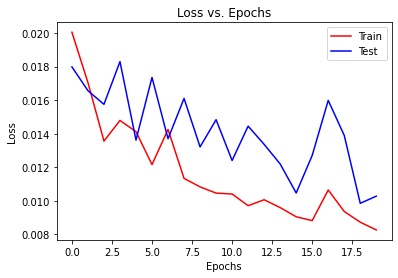

In [63]:
plt.plot(hist.history['loss'], color='red', label='Train')
plt.plot(hist.history['val_loss'], color='blue', label='Test')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc="upper right")
plt.title('Loss vs. Epochs')
plt.show()

In [64]:
checkpoint_path = "./check_points/1025_2.ckpt"
model.save_weights(checkpoint_path)

In [55]:
checkpoint_path = "./check_points/1024_1.ckpt"
model.load_weights(checkpoint_path)


Two checkpoint references resolved to different objects (<tensorflow.python.keras.layers.convolutional.Conv3DTranspose object at 0x7fc46f4b8518> and <tensorflow.python.keras.engine.base_layer.TensorFlowOpLayer object at 0x7fc46f3315c0>).

Two checkpoint references resolved to different objects (<tensorflow.python.keras.layers.convolutional.Conv3D object at 0x7fc46f454dd8> and <tensorflow.python.keras.engine.base_layer.TensorFlowOpLayer object at 0x7fc46f2d18d0>).

Two checkpoint references resolved to different objects (<tensorflow.python.keras.layers.convolutional.Conv3D object at 0x7fc46f3fb0b8> and <tensorflow.python.keras.engine.base_layer.TensorFlowOpLayer object at 0x7fc46f2d11d0>).

Two checkpoint references resolved to different objects (<tensorflow.python.keras.layers.convolutional.Conv3DTranspose object at 0x7fc46f449208> and <tensorflow.python.keras.engine.base_layer.TensorFlowOpLayer object at 0x7fc46f269be0>).

Two checkpoint references resolved to different objects (<ten

In [17]:
## 간단하게 결과 보기 위한 코드 ##
output = model.predict(sample_loader)
moved_gt = output['moved_gt']
deformation = output['deformation']

print(moved_gt.shape)

(1, 64, 128, 128, 1)


In [65]:
## 간단하게 결과 보기 위한 코드 ##
output = model.predict(sample_loader)
moved = output['moved']
deformation = output['deformation']
moved_gt = output['moved_gt']

print(moved.shape)
a = moved[0]
b = deformation[0]
c = moved_gt[0]

print(a.shape)
a = a.swapaxes(0,2) 
b = b.swapaxes(0,2)
c = c.swapaxes(0,2)
c = np.squeeze(c, axis=-1)
print(c.shape)

# a = nib.Nifti1Image(a,None) 
# b = nib.Nifti1Image(b,None)
c = nib.Nifti1Image(c,None)

# nib.save(a,'BTCV_Data/moved_1011_1.nii.gz')
# nib.save(b,'BTCV_Data/deformation_1011_1.nii.gz')
nib.save(c,'BTCV_Data/실험결과/1025_2.nii.gz')

(29, 64, 128, 128, 1)
(64, 128, 128, 1)
(128, 128, 64)


In [31]:
## 전부 결과 보기 위한 코드 ##

data_dir = "./BTCV_Data/0.name_gt"
data_list = sorted(os.listdir(data_dir))

# print(data_list[0])
output = model.predict(sample_loader)
moved = output['moved']
deformation = output['deformation']
moved_gt = output['moved_gt']

for i in range(0,29):
    c = moved_gt[i]

    c = c.swapaxes(0,2)
    c = np.squeeze(c, axis=-1)
    print(c.shape)


    c = nib.Nifti1Image(c,None)
    savename = 'BTCV_Data/Dual결과/'+ data_list[i]
    nib.save(c, savename)

(128, 128, 64)
(128, 128, 64)
(128, 128, 64)
(128, 128, 64)
(128, 128, 64)
(128, 128, 64)
(128, 128, 64)
(128, 128, 64)
(128, 128, 64)
(128, 128, 64)
(128, 128, 64)
(128, 128, 64)
(128, 128, 64)
(128, 128, 64)
(128, 128, 64)
(128, 128, 64)
(128, 128, 64)
(128, 128, 64)
(128, 128, 64)
(128, 128, 64)
(128, 128, 64)
(128, 128, 64)
(128, 128, 64)
(128, 128, 64)
(128, 128, 64)
(128, 128, 64)
(128, 128, 64)
(128, 128, 64)
(128, 128, 64)


In [33]:
## DICE 산술평균 직접 구현 ## 
def dice_mean_multilabel(y_true, y_pred, labels=13):
    
    w, h, d  = y_true.shape
    label_interaction = []
    label_union = []
    total_dice = 0
    # print(y_true.shape)
    print("----Start Mean Dice----")
    for m in range(0, labels+1):
        interact = 0
        gakgak = 0 
        for i in range(0, w):
            for j in range(0, h):
                for k in range(0, d):
                        if y_true[i][j][k] == m and y_pred[i][j][k] == m:
                            interact += 1
                        if y_true[i][j][k] == m:
                            gakgak += 1
                        if y_pred[i][j][k] == m:
                            gakgak += 1
        if interact != None:
            label_interaction.append(interact)
        else:
            label_interaction.append(0)
        if gakgak != None:
            label_union.append(gakgak)
        else:
            label_union.append(0)
        
        #print(label_interaction)
        
        dice = (label_interaction[m]*2) / label_union[m]
        
        if m == 0:
            print("background Dice: "+ str(dice))
        else:
            total_dice += dice
            print("Label: "+ str(m) + "    Dice: "+ str(dice))
        
    print("total_dice: " + str(total_dice / (labels)))

In [34]:
# DICE Voxel Union #
def dice_voxel_union_multilabel(y_true, y_pred, labels=13):
    label_interaction = []
    label_union = []
    total_dice = 0
    smooth = 0.0001
    filename4 = "./BTCV_Data/14onehot_gt.nii.gz" 
    static_gt = nib.load(filename4).get_fdata()
    static_gt = static_gt.astype(np.float32)
    
    # print(y_true.shape)
    print("----Start Dice Voxel----")

    y_true_f = K.flatten(K.one_hot(K.cast(y_true, 'int32'), num_classes=14)[..., 1:])
    y_pred_f = K.flatten(static_gt[...,1:])
    intersect = K.sum(y_true_f * y_pred_f, axis=-1)
    denom = K.sum(y_true_f + y_pred_f, axis=-1)

    dice = K.mean((2. * intersect / (denom + smooth)))

    print("Total Dice: "+ str(dice))
    print("Total intersection: "+str(intersect))
    print("Total Union: "+str(denom))

In [35]:
# DICE Voxel Union #
def dice_all_union_multilabel(y_true, y_pred, labels=13):
    w, h, d   = y_true.shape
    label_interaction = []
    label_union = []
    total_dice = 0
    smooth = 0.0001
    print("----Start Dice All----")
    new_true = np.zeros((w,h,d))
    new_pred = np.zeros((w,h,d))

#     print(new_true.shape)
    for i in range(0, w):
        for j in range(0, h):
            for k in range(0, d):
                if y_true[i][j][k] != 0:
                    new_true[i][j][k] = 1
                if y_pred[i][j][k] != 0:
                    new_pred[i][j][k] = 1
    
    y_true_f = K.flatten(new_true[...])
    y_pred_f = K.flatten(new_pred[...])
    intersect = K.sum(y_true_f * y_pred_f, axis=-1)
    denom = K.sum(y_true_f + y_pred_f, axis=-1)

    dice = K.mean((2. * intersect / (denom + smooth)))
    print("Total Dice: "+ str(dice))
    print("Total intersection: "+str(intersect))
    print("Total Union: "+str(denom))

In [36]:
filename1 = "./BTCV_Data/Dual결과/1.nii.gz"
filename2 = "./BTCV_Data/0.name_gt/40.nii.gz"

x1 = nib.load(filename1).get_fdata()
x1 = x1.astype(np.float32)
x2 = nib.load(filename2).get_fdata()

x2 = x2.astype(np.float32)    
# print(x1.shape)
# print(x2.shape)


dice_mean_multilabel(x1, x2)
dice_voxel_union_multilabel(x1, x2)
dice_all_union_multilabel(x1,x2)

----Start Mean Dice----
background Dice: 0.9686978195176386
Label: 1    Dice: 0.22704367301231804
Label: 2    Dice: 0.15719718796819176
Label: 3    Dice: 0.5883335321483956
Label: 4    Dice: 0.0
Label: 5    Dice: 0.0
Label: 6    Dice: 0.46764660796102947
Label: 7    Dice: 0.36664597558452305
Label: 8    Dice: 0.0009375
Label: 9    Dice: 0.0
Label: 10    Dice: 0.01627906976744186
Label: 11    Dice: 0.12708892098205074
Label: 12    Dice: 0.0
Label: 13    Dice: 0.028328611898016998
total_dice: 0.1522693137939975
----Start Dice Voxel----
Total Dice: tf.Tensor(0.35022888, shape=(), dtype=float32)
Total intersection: tf.Tensor(23258.0, shape=(), dtype=float32)
Total Union: tf.Tensor(132816.0, shape=(), dtype=float32)
----Start Dice All----
Total Dice: tf.Tensor(0.5370437292667722, shape=(), dtype=float64)
Total intersection: tf.Tensor(35664.0, shape=(), dtype=float64)
Total Union: tf.Tensor(132816.0, shape=(), dtype=float64)
